# Week 5 — Unsupervised Learning: Clustering
**Dataset:** Mall Customer Segmentation  
**Algorithms:** K-Means, DBSCAN  
**Visualization:** PCA, t-SNE

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'tab10'
print('All imports successful.')

All imports successful.


## 2. Load Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
print('Shape:', df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. EDA

In [3]:
# Basic info
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Null Values ===')
print(df.isnull().sum())
print('\n=== Descriptive Stats ===')
df.describe()

=== Data Types ===
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

=== Null Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Descriptive Stats ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


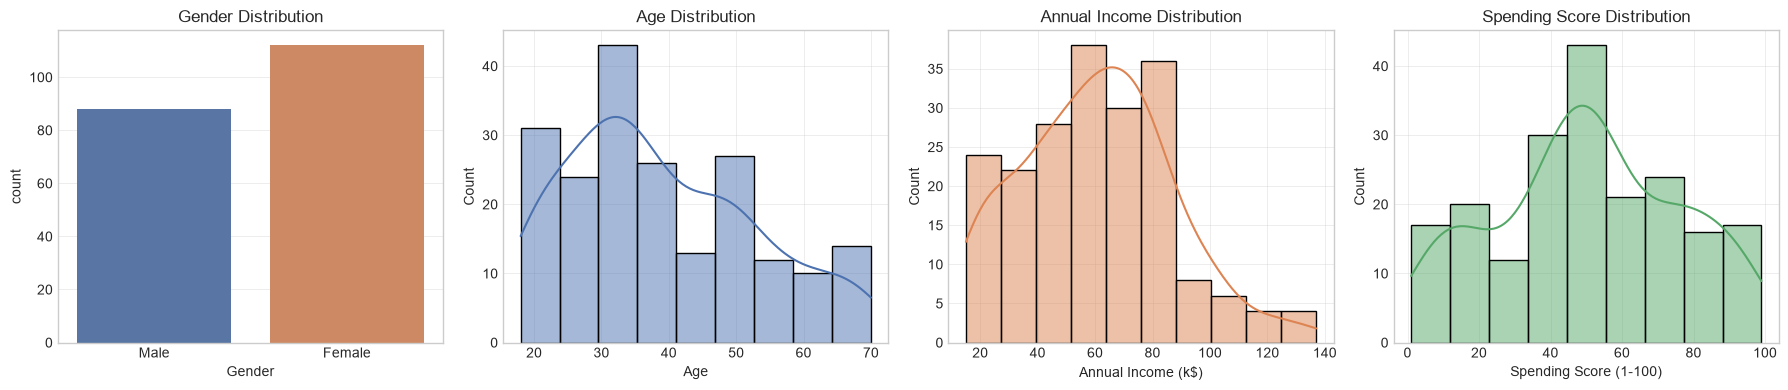

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.countplot(data=df, x='Gender', ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Gender Distribution')

sns.histplot(df['Age'], kde=True, ax=axes[1], color='#4C72B0')
axes[1].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[2], color='#DD8452')
axes[2].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[3], color='#55A868')
axes[3].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

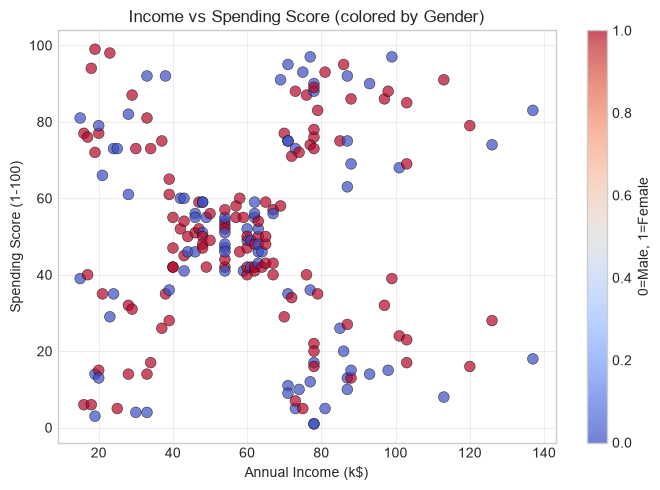

In [5]:
df_plot = df.copy()
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df_plot['Annual Income (k$)'],
    df_plot['Spending Score (1-100)'],
    c=df_plot['Gender'].map({'Male': 0, 'Female': 1}),
    cmap='coolwarm', alpha=0.7, edgecolors='k', linewidths=0.4, s=60
)
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('Income vs Spending Score (colored by Gender)')
plt.colorbar(scatter, ax=ax, label='0=Male, 1=Female')
plt.tight_layout()
plt.savefig('eda_income_vs_spending.png', dpi=150, bbox_inches='tight')
plt.show()

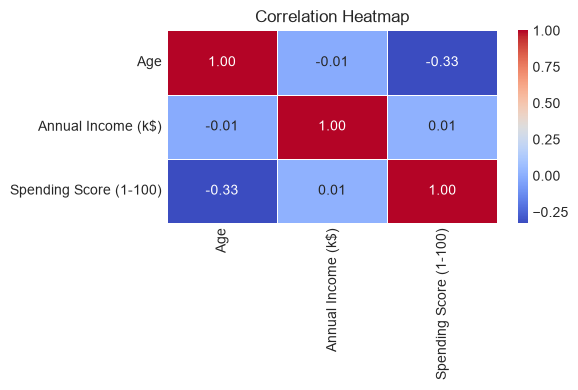

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
numeric_df = df.drop(columns=['CustomerID', 'Gender'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing

In [7]:
df_clean = df.drop(columns=['CustomerID'])

le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Female=0, Male=1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)

print('Preprocessed shape:', X_scaled.shape)
X_scaled.head()

Preprocessed shape: (200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## 5. Elbow Method — Optimal K

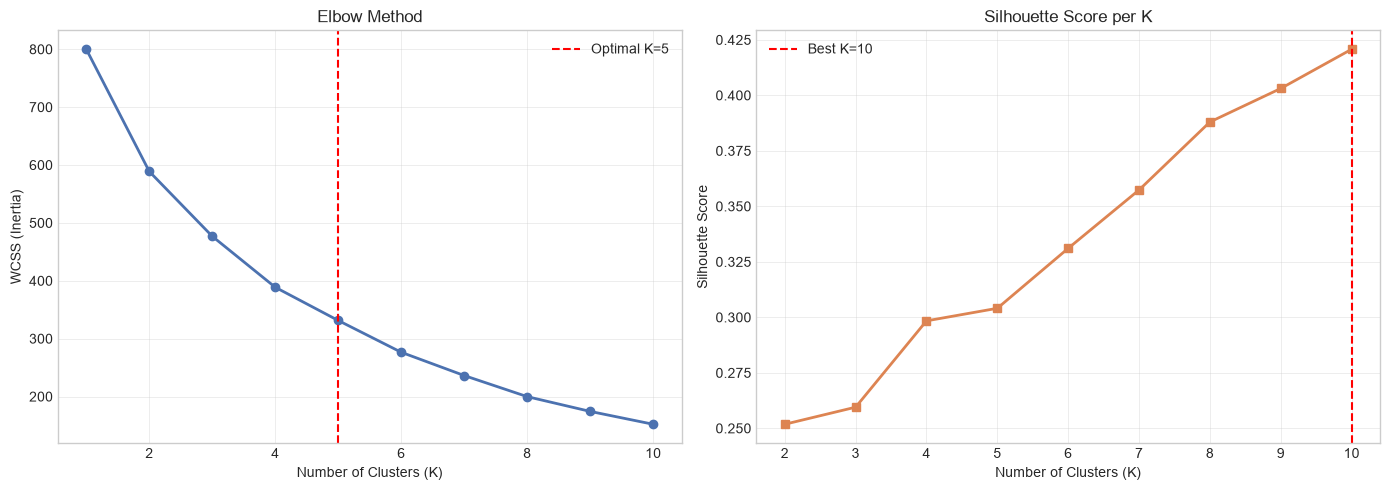

Best K by Silhouette: 10


In [8]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(range(1, 11), wcss, marker='o', color='#4C72B0', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
axes[0].legend()

# Silhouette scores
axes[1].plot(list(K_range), silhouette_scores, marker='s', color='#DD8452', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')
best_k_sil = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best K by Silhouette: {best_k_sil}')

## 6. K-Means Clustering

In [9]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_result = df_clean.copy()
df_result['KMeans_Cluster'] = kmeans_labels

print(f'K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print('\nCluster sizes:')
print(df_result['KMeans_Cluster'].value_counts().sort_index())

K-Means Silhouette Score: 0.3041

Cluster sizes:
KMeans_Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


In [10]:
df_profile = df_result.copy()
df_profile['Gender'] = df_profile['Gender'].map({0: 'Female', 1: 'Male'})

profile = df_result.groupby('KMeans_Cluster').mean().round(2)
profile['Count'] = df_result['KMeans_Cluster'].value_counts().sort_index()
print('\n=== Cluster Profiles (Mean Values) ===')
print(profile)


=== Cluster Profiles (Mean Values) ===
                Gender    Age  Annual Income (k$)  Spending Score (1-100)  \
KMeans_Cluster                                                              
0                 0.46  32.69               86.54                   82.13   
1                 0.45  36.48               89.52                   18.00   
2                 0.00  49.81               49.23                   40.07   
3                 0.41  24.91               39.72                   61.20   
4                 1.00  55.71               53.69                   36.77   

                Count  
KMeans_Cluster         
0                  39  
1                  29  
2                  43  
3                  54  
4                  35  


In [11]:
# Cluster naming based on Income & Spending Score patterns
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

# Auto-assign names based on income/spending
def name_cluster(row):
    inc = row['Annual Income (k$)']
    spd = row['Spending Score (1-100)']
    if inc > 60 and spd > 60:
        return 'High Income, High Spenders'
    elif inc > 60 and spd < 40:
        return 'High Income, Low Spenders'
    elif inc < 40 and spd > 60:
        return 'Low Income, High Spenders'
    elif inc < 40 and spd < 40:
        return 'Low Income, Low Spenders'
    else:
        return 'Average'

profile['Segment Name'] = profile.apply(name_cluster, axis=1)
print(profile[['Annual Income (k$)', 'Spending Score (1-100)', 'Count', 'Segment Name']])

                Annual Income (k$)  Spending Score (1-100)  Count  \
KMeans_Cluster                                                      
0                            86.54                   82.13     39   
1                            89.52                   18.00     29   
2                            49.23                   40.07     43   
3                            39.72                   61.20     54   
4                            53.69                   36.77     35   

                              Segment Name  
KMeans_Cluster                              
0               High Income, High Spenders  
1                High Income, Low Spenders  
2                                  Average  
3                Low Income, High Spenders  
4                                  Average  


## 7. DBSCAN Clustering

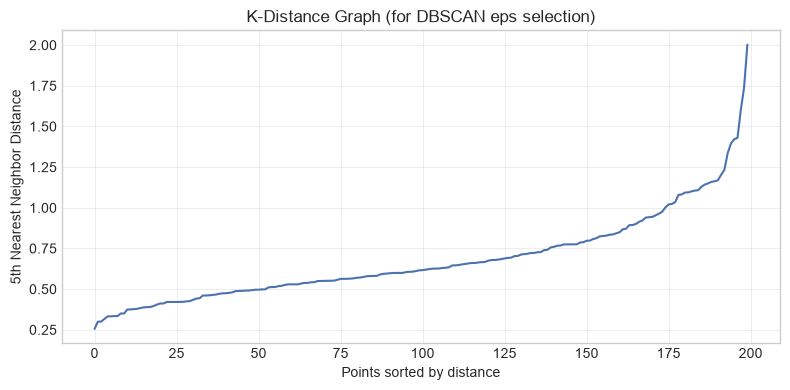

In [12]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # 4th nearest neighbor distance

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(distances, color='#4C72B0')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('5th Nearest Neighbor Distance')
ax.set_title('K-Distance Graph (for DBSCAN eps selection)')
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_result['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN Clusters found: {n_clusters_db}')
print(f'Noise points (label=-1): {n_noise}')
print('\nCluster distribution:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

if n_clusters_db > 1:
    valid_mask = dbscan_labels != -1
    sil = silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask])
    print(f'\nDBSCAN Silhouette Score (excl. noise): {sil:.4f}')

DBSCAN Clusters found: 5
Noise points (label=-1): 19

Cluster distribution:
-1    19
 0     9
 1    94
 2    40
 3    26
 4    12
Name: count, dtype: int64

DBSCAN Silhouette Score (excl. noise): 0.2273


## 8. PCA Visualization

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}')
print(f'PC1: {pca.explained_variance_ratio_[0]:.2%} | PC2: {pca.explained_variance_ratio_[1]:.2%}')

Explained variance by 2 PCs: 59.92%
PC1: 33.69% | PC2: 26.23%


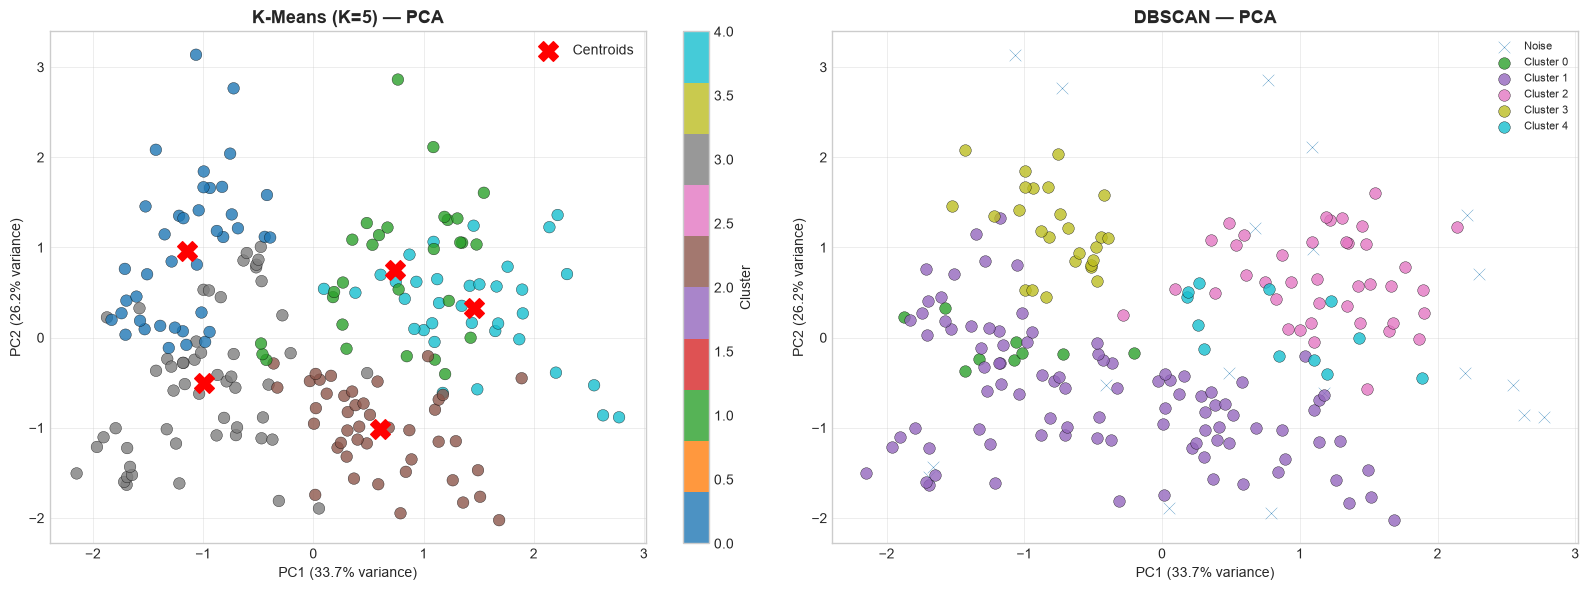

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means PCA plot
scatter1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap=PALETTE,
    alpha=0.8, edgecolors='k', linewidths=0.3, s=70
)
# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=200, c='red', marker='X', zorder=5, label='Centroids'
)
axes[0].set_title(f'K-Means (K={OPTIMAL_K}) — PCA', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN PCA plot
unique_labels = sorted(set(dbscan_labels))
colors_db = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for lbl, col in zip(unique_labels, colors_db):
    mask = dbscan_labels == lbl
    label_name = f'Noise' if lbl == -1 else f'Cluster {lbl}'
    marker = 'x' if lbl == -1 else 'o'
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[col], label=label_name, alpha=0.8,
        edgecolors='k', linewidths=0.3, s=70, marker=marker
    )
axes[1].set_title('DBSCAN — PCA', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. t-SNE Visualization

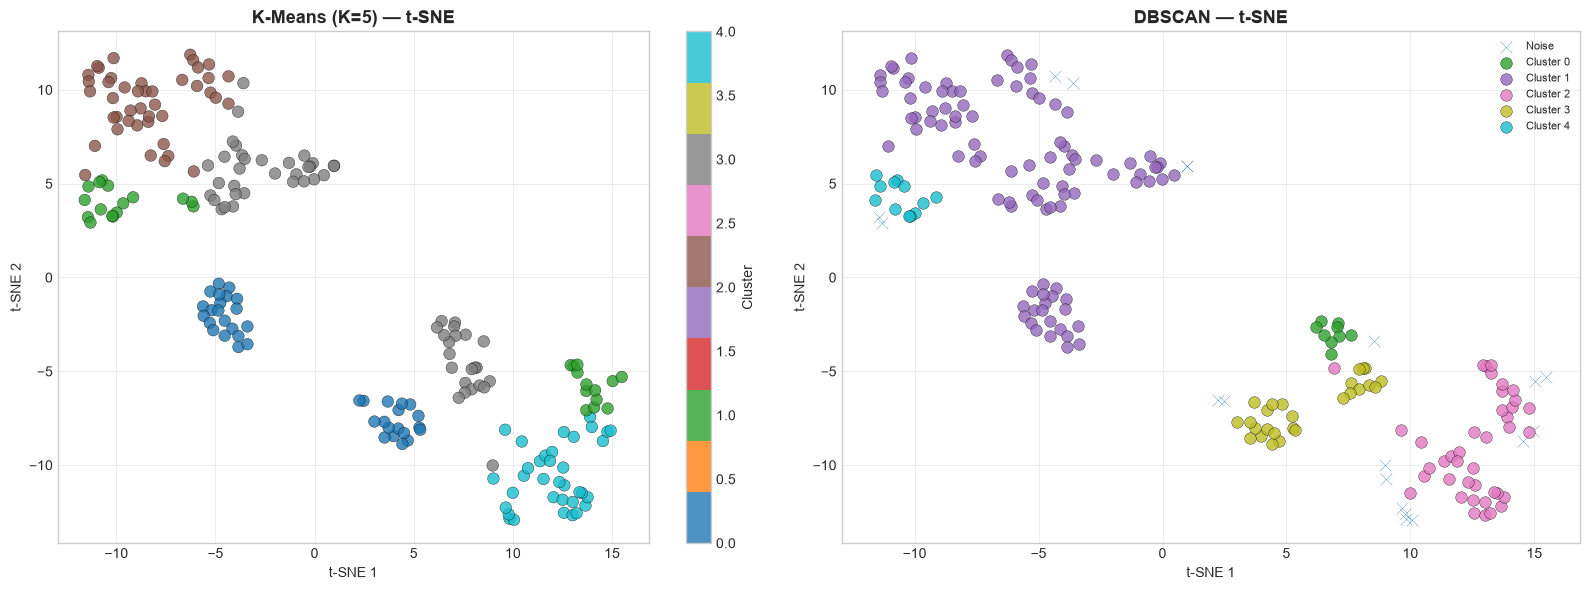

In [23]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=kmeans_labels, cmap=PALETTE,
    alpha=0.8, edgecolors='k', linewidths=0.3, s=70
)
axes[0].set_title(f'K-Means (K={OPTIMAL_K}) — t-SNE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

for lbl, col in zip(unique_labels, colors_db):
    mask = dbscan_labels == lbl
    label_name = f'Noise' if lbl == -1 else f'Cluster {lbl}'
    marker = 'x' if lbl == -1 else 'o'
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[col], label=label_name, alpha=0.8,
        edgecolors='k', linewidths=0.3, s=70, marker=marker
    )
axes[1].set_title('DBSCAN — t-SNE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. K-Means on Income vs Spending (2D — most interpretable)

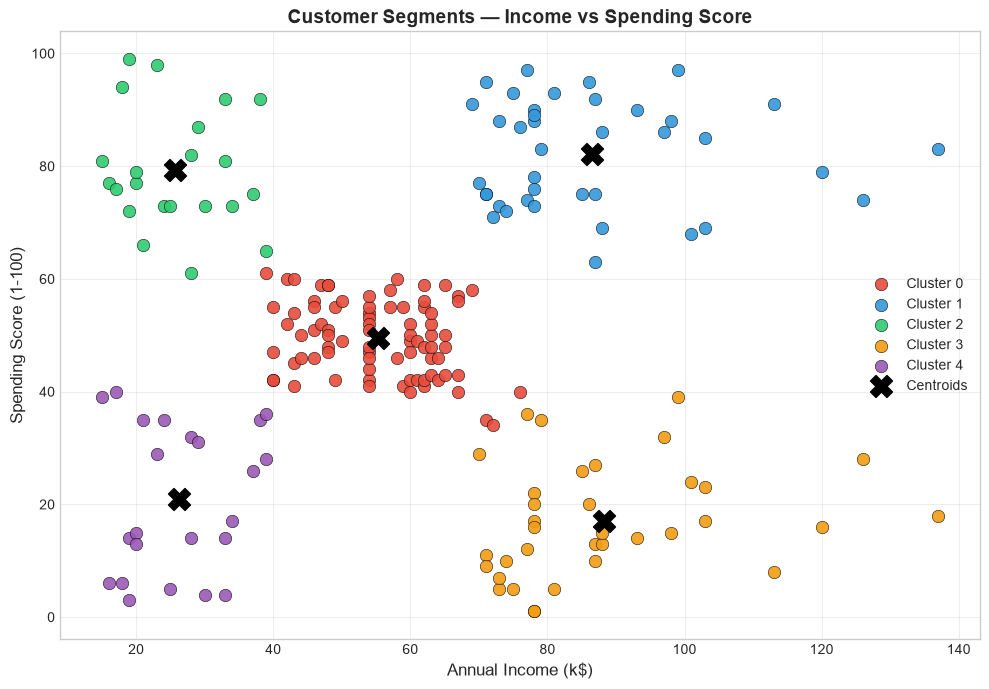

In [19]:
# 2D K-Means specifically on Income & Spending (most business-relevant)
X_2d = df_clean[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
X_2d_scaled = StandardScaler().fit_transform(X_2d)

km_2d = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels_2d = km_2d.fit_predict(X_2d_scaled)

segment_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
segment_labels = [
    'High Income, High Spenders',
    'High Income, Low Spenders',
    'Average',
    'Low Income, High Spenders',
    'Low Income, Low Spenders'
]

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(5):
    mask = labels_2d == i
    ax.scatter(
        X_2d.loc[mask, 'Annual Income (k$)'],
        X_2d.loc[mask, 'Spending Score (1-100)'],
        c=segment_colors[i], label=f'Cluster {i}',
        s=80, edgecolors='k', linewidths=0.4, alpha=0.9
    )

# Plot centroids in original scale
centroids_2d = StandardScaler().fit(X_2d).inverse_transform(km_2d.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=250, c='black', marker='X', zorder=5, label='Centroids')

ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.set_title('Customer Segments — Income vs Spending Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('kmeans_income_spending.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Model Comparison

In [22]:
print('           CLUSTERING MODEL COMPARISON')

km_sil = silhouette_score(X_scaled, kmeans_labels)
print(f'K-Means (K=5):')
print(f'  Silhouette Score : {km_sil:.4f}')
print(f'  Clusters Found   : {OPTIMAL_K}')
print(f'  Noise Points     : 0 (K-Means assigns all points)')

print(f'\nDBSCAN (eps=0.8, min_samples=5):')
if n_clusters_db > 1:
    valid_mask = dbscan_labels != -1
    db_sil = silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask])
    print(f'  Silhouette Score : {db_sil:.4f}')
print(f'  Clusters Found   : {n_clusters_db}')
print(f'  Noise Points     : {n_noise}')

print('Best Model: K-Means — cleaner, interpretable segments')
print('DBSCAN useful for anomaly/outlier detection')

           CLUSTERING MODEL COMPARISON
K-Means (K=5):
  Silhouette Score : 0.3041
  Clusters Found   : 5
  Noise Points     : 0 (K-Means assigns all points)

DBSCAN (eps=0.8, min_samples=5):
  Silhouette Score : 0.2273
  Clusters Found   : 5
  Noise Points     : 19
Best Model: K-Means — cleaner, interpretable segments
DBSCAN useful for anomaly/outlier detection


## 12. Use Case Suggestion for Zynxis

### Applying Customer Segmentation Insights to Zynxis

The clustering analysis identified **5 distinct customer segments** based on Annual Income and Spending Score. Below is how Zynxis can operationalize these insights:

---

#### Segment → Business Action Mapping

| Cluster | Profile | Zynxis Action |
|---------|---------|---------------|
| High Income, High Spenders | Already engaged, high value | Loyalty programs, premium tiers, upsell |
| High Income, Low Spenders | Potential untapped value | Targeted campaigns, personalized offers |
| Low Income, High Spenders | Highly engaged, budget-limited | Discount bundles, referral rewards |
| Low Income, Low Spenders | Disengaged, cost-sensitive | Re-engagement emails, free features |
| Average | Moderate engagement | A/B test promotions to push them upward |

---

#### If applied to Intern/Employee Data:
- **Performance Grouping:** Cluster interns by task completion rate, code quality scores, and peer ratings → assign tailored mentorship tracks per cluster.
- **Workload Balancing:** Identify overloaded vs underutilized interns using DBSCAN noise detection — noise points flag outliers needing immediate attention.
- **Skill Gap Analysis:** PCA components could represent skill dimensions; clusters reveal cohorts with similar skill gaps, enabling batch training sessions.

---

**Recommended Next Steps for Zynxis:**
1. Deploy K-Means segmentation on live user data (5 clusters confirmed optimal)
2. Integrate cluster labels into CRM for personalized outreach
3. Re-run clustering quarterly to detect segment drift
4. Use DBSCAN in parallel to flag anomalous users (potential churn risk or fraud)